In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# DATA INSPECTION

df =pd.read_csv("./data/heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


<Axes: xlabel='num', ylabel='Count'>

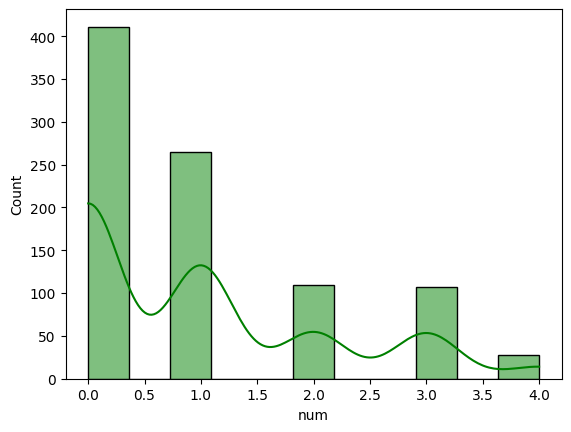

In [16]:
sns.histplot(df['num'], kde=True, color="green")

In [17]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


In [18]:
import pandas as pd
df["target"]=(df["num"]>0).astype(int)
print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='Count'>

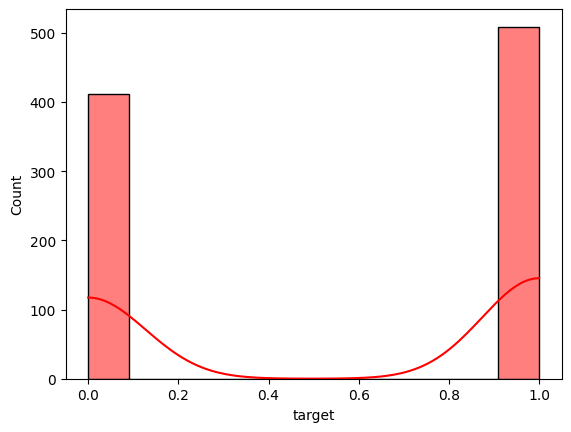

In [19]:
sns.histplot(df['target'], kde=True, color="red")

done


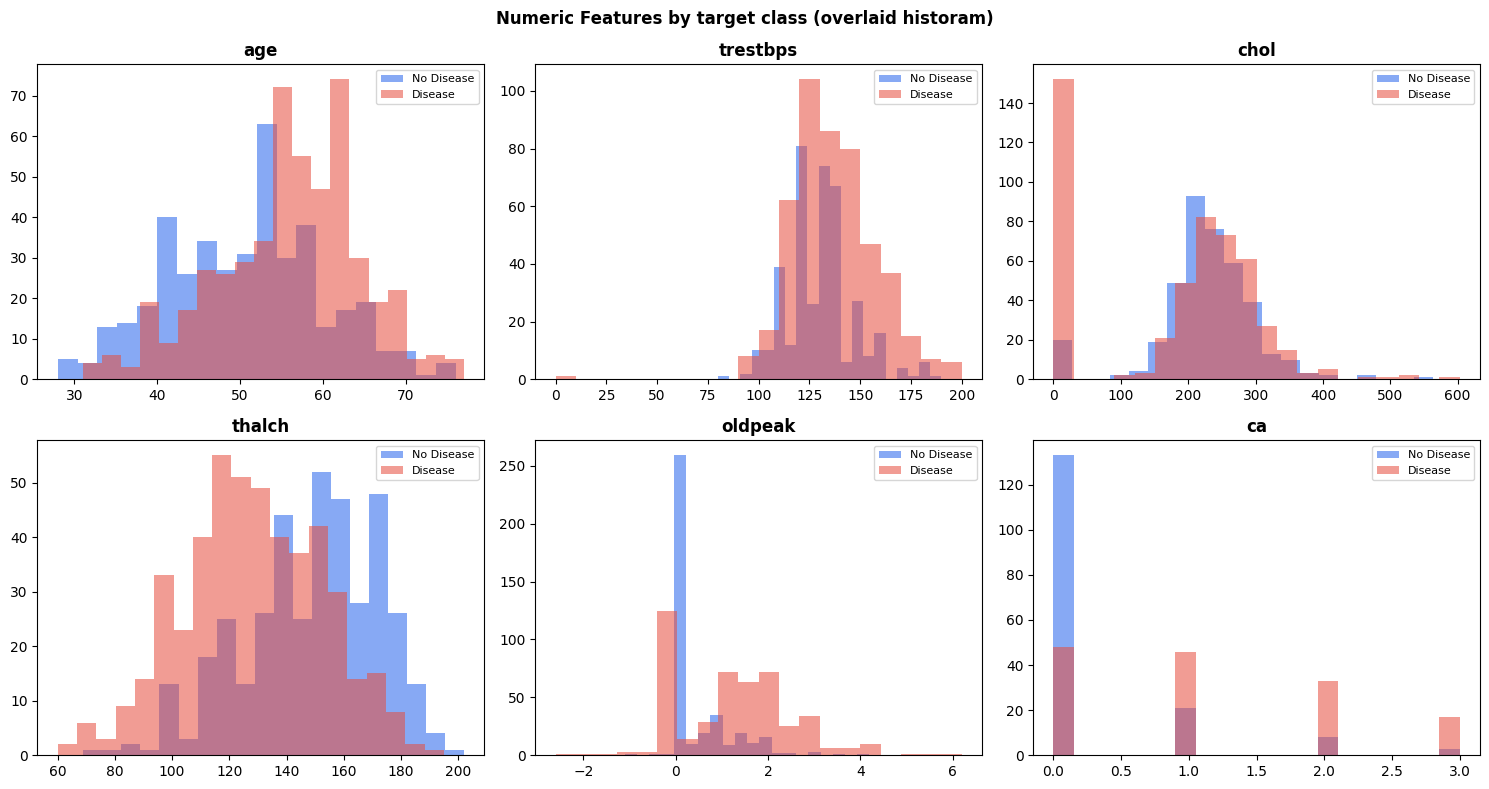

In [26]:
num_cols=["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes=plt.subplots(2,3, figsize=(15, 8))
axes=axes.flatten()
for i, col in enumerate(num_cols):
    for label, color, name in [(0, "#2563EB", 'No Disease'), (1, '#E74C3C', 'Disease')]:
        subset=df[df['target']==label][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.55, label=name, color=color)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Numeric Features by target class (overlaid historam)', fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_vs_target_hist.png', dpi=130)
    


In [27]:
fig, axes=plt.subplots(1, 6, figsize=(18, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('target (0=no disease, 1=disease')
plt.suptitle('')
plt.tight_layout()
plt.savefig('numeric_vs_target-box.png', dpi=130)
plt.close()
print("done")

done


In [33]:
cat_cols=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']
fig, axes=plt.subplots(2, 4, figsize=(10, 9))
axes=axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()
    rate.plot(kind='bar', ax=axes[i], color='#1E5FA8', edgecolor='white')
    axes[i].axhline(df['target'].mean(), color='red', linestyle='--', label=f'Overall rate: {df["target"].mean():.2f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('% with disease')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=40)
plt.suptitle('Disease Rate by Category (red line = overall average rate)', fontweight='bold')
plt.tight_layout()
# plt.savefig('categorical_vs_target.png', dpi=130)
plt.close()

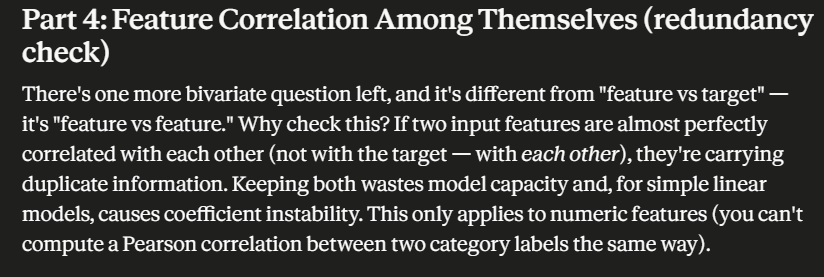

In [35]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Matrix (numeric features + target)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=130)
plt.close()
print(corr['target'].sort_values(ascending=False))

target      1.000000
ca          0.455599
oldpeak     0.385528
age         0.282700
trestbps    0.106233
chol       -0.230583
thalch     -0.394503
Name: target, dtype: float64


## Part 6: Missing Data Audit — what's actually missing, and what to do about each column

Recall the missing-value counts from earlier## 

In [36]:
miss = df.isnull().sum()
pct = (100*miss/len(df)).round(1)
report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
report = report[report.missing_count > 0].sort_values('missing_pct', ascending=False)
print(report)
print()
print('zeros in chol:', (df['chol']==0).sum())
print('zeros in trestbps:', (df['trestbps']==0).sum())

          missing_count  missing_pct
ca                  611         66.4
thal                486         52.8
slope               309         33.6
fbs                  90          9.8
oldpeak              62          6.7
trestbps             59          6.4
exang                55          6.0
thalch               55          6.0
chol                 30          3.3
restecg               2          0.2

zeros in chol: 172
zeros in trestbps: 1


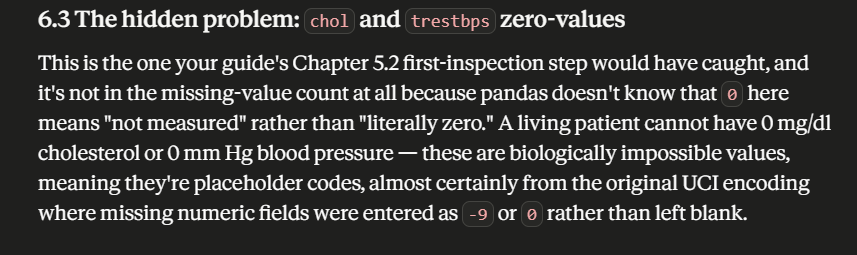

In [37]:
print('chol==0 rows by hospital:')
print(df[df['chol']==0]['dataset'].value_counts())
print()
print('trestbps==0 rows by hospital:')
print(df[df['trestbps']==0]['dataset'].value_counts())

chol==0 rows by hospital:
dataset
Switzerland      123
VA Long Beach     49
Name: count, dtype: int64

trestbps==0 rows by hospital:
dataset
VA Long Beach    1
Name: count, dtype: int64


The Code above Confirms it — every single Switzerland row (all 123) has chol=0, plus 49 VA Long Beach rows. That's not real cholesterol data; that's an entire site's worth of "not recorded" entries sitting disguised as zero. If we left these as-is, the model would see "cholesterol = 0" as a real, extremely low value, which would be medically nonsensical and would also (again) act as a backdoor "which hospital are you from" signal, since it's perfectly correlated with Switzerland.


Fix, and why this specific fix: convert these biologically-impossible zeros to NaN first — that reclassifies them as honest missing values instead of fake real ones — then apply the same median imputation rule from 6.2. The single trestbps=0 row gets the same treatment, though it's rare enough (1 row) that it barely matters either way; I'm including it for consistency, not because it changes much numerically.

## 6.4 Putting it together — the cleaning code

In [46]:
# Step 0: build the target, drop the leakage-prone / non-feature columns
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['id', 'num', 'dataset'])

# id -> just a row index, not a feature
# num -> replaced by target, would leak the answer if kept
# dataset -> hospital-site artifact, explained in Part 3 + Part 6.1



KeyError: 'num'

In [48]:
# Step 1: convert biologically-impossible zeros to NaN (chol, trestbps)
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)


# Step 2: drop ca and thal — too much hospital-driven missingness (>60%)
df = df.drop(columns=['ca', 'thal'])

# Step 3: impute slope (33.6% missing, kept) with most frequent category
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

# Step 4: impute remaining small-gap numeric columns with median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col] = df[col].fillna(df[col].median())

# Step 5: impute remaining small-gap categorical/boolean columns with mode
for col in ['fbs', 'restecg', 'exang']:
    df[col] = df[col].fillna(df[col].mode()[0])




In [49]:
print("Missing values remaining:")
print(df.isnull().sum().sum())
print()
print("Final columns:", df.columns.tolist())
print()
print(df.head(3))

Missing values remaining:
0

Final columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'target']

   age   sex              cp  trestbps   chol    fbs         restecg  thalch  \
0   63  Male  typical angina     145.0  233.0   True  lv hypertrophy   150.0   
1   67  Male    asymptomatic     160.0  286.0  False  lv hypertrophy   108.0   
2   67  Male    asymptomatic     120.0  229.0  False  lv hypertrophy   129.0   

   exang  oldpeak        slope  target  
0  False      2.3  downsloping       0  
1   True      1.5         flat       1  
2   True      2.6         flat       1  


Zero missing values left, and 11 features plus the target. Notice the order I did this in matters: I converted the fake zeros to NaN before imputing, not after — if you impute first and clean the zero-artifact second, the median calculation for chol would have been dragged down by 172 fake zeros, giving you a wrong (too-low) median to fill the real gaps with. Sequencing the cleaning steps correctly is as important as choosing the right step.


## 6.5 Quick verdict table for this section

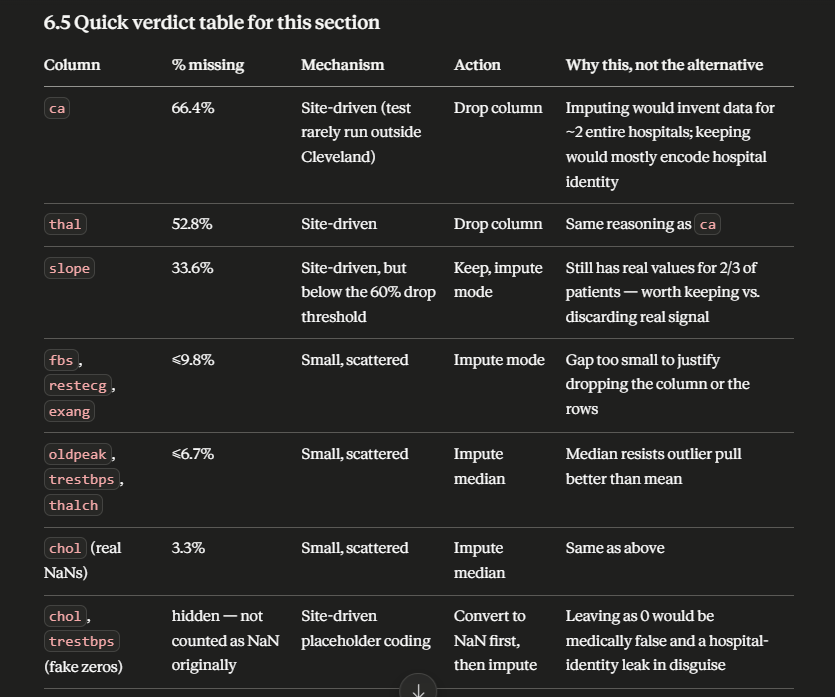

## Part 7: Encoding Categorical Features

### 7.1 The core question first: why encode at all?

A model is just arithmetic — it multiplies numbers, adds them, compares them. It cannot multiply "Male" by a coefficient. Every categorical column (sex, cp, fbs, restecg, exang, slope) has to become numeric before any scikit-learn model will accept it. How you turn a category into a number is the part that trips people up, because there are two genuinely different methods and picking the wrong one for a given column quietly damages the model.

## 7.2 Ordinal encoding vs one-hot encoding — the actual decision rule

Ordinal encoding assigns each category an integer: flat → 0, upsloping → 1, downsloping → 2. This is only correct when the categories have a real, meaningful order — when category 2 is genuinely "more" of something than category 1 in a way the model should be able to use (e.g., interpolate or extrapolate along).


One-hot encoding creates one new 0/1 column per category: cp_asymptomatic, cp_typical_angina, cp_non_anginal, cp_atypical_angina — each row has a 1 in exactly one of these and 0 in the rest. This is correct when categories have no order — they're just different labels sitting side by side.

Why getting this backwards actually hurts the model, not just style: if you ordinal-encode cp (chest pain type) as asymptomatic=0, atypical=1, non-anginal=2, typical=3, you've told the model "typical angina is numerically 3x further from asymptomatic than atypical is" — a relationship that doesn't exist medically. Linear models will fit a slope through that fake number line; even tree models, which are more robust to this, can still split on the wrong threshold because of how it groups categories together by accident of numbering. The damage is invented structure that isn't in the real world.

In [51]:

# ---------------------------------------------------------------------------
# STEP 1 — Boolean columns: fbs, exang
# ---------------------------------------------------------------------------
# These were loaded by pandas as the strings/objects True/False (or actual
# Python bool). .astype(int) converts True -> 1, False -> 0 directly.
# Why not one-hot here? One-hot on a 2-category column would just create a
# second redundant column that is exactly 1 minus the first — wasted space,
# no new information. A single 0/1 column already captures everything.
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# ---------------------------------------------------------------------------
# STEP 2 — sex: also binary, but starts as text ("Male"/"Female"), not bool
# ---------------------------------------------------------------------------
# map() takes a dictionary {old_value: new_value} and replaces every
# matching entry in the column. We choose Male=1, Female=0 — the direction
# is arbitrary (could be flipped) but must be documented, because later
# anyone reading the model's coefficients needs to know which way "1" points.
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

# ---------------------------------------------------------------------------
# STEP 3 — slope: the ONE truly ordinal categorical column (see Part 7.2)
# ---------------------------------------------------------------------------
# We manually define the order as a dictionary, low to high severity, based
# on the disease-rate evidence from bivariate analysis:
#   upsloping (38% disease)  -> 0   (best / least concerning)
#   flat       (77% disease)  -> 1
#   downsloping(78% disease)  -> 2   (worst / most concerning)
# map() again does the substitution. This is exactly ordinal encoding:
# the resulting numbers 0,1,2 have real meaning as "how bad is the slope".
slope_order = {'upsloping': 0, 'flat': 1, 'downsloping': 2}
df['slope'] = df['slope'].map(slope_order)

# ---------------------------------------------------------------------------
# STEP 4 — cp and restecg: NOT ordinal -> one-hot encode
# ---------------------------------------------------------------------------
# pd.get_dummies() is pandas' one-hot encoder. For a column with k categories
# it creates k new 0/1 columns, one per category, and removes the original
# text column automatically.
#
# Arguments used:
#   columns=[...]   -> only these columns get one-hot encoded; everything
#                      else in the DataFrame passes through untouched.
#   drop_first=True -> drops ONE of the k generated columns per feature.
#                      Why: if you know the values of all-but-one of the
#                      dummy columns, the last one is fully determined
#                      (if cp is not asymptomatic, not non-anginal, and not
#                      typical angina, it MUST be atypical angina). Keeping
#                      all k columns means one is pure redundant information
#                      — this is called the "dummy variable trap" and it
#                      causes instability in linear models specifically
#                      (multicollinearity). Tree models don't strictly need
#                      drop_first, but it's harmless for them and required
#                      for safety with linear/logistic models, so we keep it
#                      on by default.
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

df.to_csv('heart_disease_encoded.csv', index=False)

KeyError: "None of [Index(['cp', 'restecg'], dtype='str')] are in the [columns]"

In [54]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.to_csv('heart_disease_encodeds.csv', index=False)

## Part 9: Train/Test Split — and why it happens before scaling, not after

### 9.1 The leakage rule from your guide, made concrete

Chapter 7.1 of your field guide states the key rule: fit all transformers on training data only. Here's exactly what that means and why it matters with real numbers from this dataset.


If you compute the mean and standard deviation of age using all 920 rows and then use those numbers to scale every row, you've let information from the test set (which is supposed to represent "future unseen patients") leak into the numbers used to train the model. It's a small leak, but it's a real one — the model gets a tiny, artificial advantage that won't exist when it sees a genuinely new patient. The fix is mechanical: split the data first, fit the scaler on the train portion only, then apply that same already-fitted scaler to the test portion.

In [56]:

from sklearn.model_selection import train_test_split


# ---------------------------------------------------------------------------
# Separate inputs (X) from the answer (y)
# ---------------------------------------------------------------------------
# X = every column except 'target' -> df.drop(columns=['target']) returns a
#     NEW DataFrame with that column removed (the original df is untouched
#     unless you reassign it, which is what we do here).
# y = just the 'target' column, pulled out as its own Series.
X = df.drop(columns=['target'])
y = df['target']

# ---------------------------------------------------------------------------
# train_test_split() arguments explained one by one
# ---------------------------------------------------------------------------
# X, y            -> the full feature table and the full label column. The
#                    function will split BOTH the same way, row for row, so
#                    a row's features and its label always stay matched.
# test_size=0.2   -> hold back 20% of rows for testing, train on the other
#                    80%. 20% is a common default: large enough to give a
#                    statistically meaningful evaluation, small enough that
#                    the model still has most of the data to learn from.
# random_state=42 -> seeds the random number generator that decides WHICH
#                    rows go to train vs test. Without fixing this seed, you
#                    would get a different split every time you re-run the
#                    code, making results impossible to reproduce or compare
#                    across experiments. 42 has no special meaning — any
#                    fixed integer works, it just needs to be FIXED.
# stratify=y      -> this is important and specific to classification.
#                    Without it, train_test_split picks rows uniformly at
#                    random, which on a 55%/45% target could by chance
#                    produce a test set that's 70%/30% — distorting your
#                    evaluation. stratify=y forces the split to preserve the
#                    same disease/no-disease RATIO in both train and test as
#                    exists in the full dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print()
print("Target balance in train:")
print(y_train.value_counts(normalize=True).round(3))
print("Target balance in test:")
print(y_test.value_counts(normalize=True).round(3))

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

Train shape: (736, 14)
Test shape : (184, 14)

Target balance in train:
target
1    0.553
0    0.447
Name: proportion, dtype: float64
Target balance in test:
target
1    0.554
0    0.446
Name: proportion, dtype: float64


# Part 10: Scaling — why some models need it and others don't

## 10.1 The actual reason, not just "always scale your data"

Look at the raw ranges of your numeric features: age runs roughly 28–77, chol runs roughly 100–600, oldpeak runs roughly -2 to 6. For distance-based or coefficient-based models (logistic regression, KNN, SVM), a feature with a bigger numeric range can dominate the math purely because of its scale, not because it's actually more important. chol ranging into the hundreds would swamp oldpeak ranging in single digits, even if oldpeak is the medically stronger signal — we proved earlier that oldpeak correlates more strongly with the target (0.39 vs chol's -0.23).


Tree-based models (Random Forest, Gradient Boosting) don't have this problem. A decision tree splits on thresholds like "is chol > 250?" — the absolute scale of the number doesn't change which side of that threshold a value falls on, so trees are scale-invariant. This is why we'll build two model pipelines below: one with scaling (for a linear baseline) and one without (for the tree ensemble) — not because one pipeline is "more correct" universally, but because each model type has different mathematical requirements.

In [57]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# ---------------------------------------------------------------------------
# StandardScaler: what the math actually does
# ---------------------------------------------------------------------------
# For each column, StandardScaler computes:
#     scaled_value = (original_value - mean) / standard_deviation
# After this, every numeric column has mean 0 and standard deviation 1.
# This puts age, chol, oldpeak etc. all on the SAME numeric footing, so no
# single feature dominates a linear model's math just by having bigger raw
# numbers.
scaler = StandardScaler()

# .fit_transform() on TRAIN does two things in one call:
#   1. fit  -> calculates the mean and std FROM X_train only (never X_test —
#              this is the leakage rule from Part 9.1 applied directly).
#   2. transform -> applies (value - mean)/std using those just-computed
#              numbers, returning the scaled training data.
X_train_scaled = scaler.fit_transform(X_train)

# .transform() on TEST (no .fit here!) reuses the mean/std that were
# already learned from training data. This is the correct way to scale
# test data: using the SAME formula coefficients as training, never
# recomputing fresh mean/std from the test set itself.
X_test_scaled = scaler.transform(X_test)

# Both StandardScaler outputs are plain numpy arrays, not DataFrames, so we
# wrap them back into DataFrames with the original column names for
# readability later (e.g. when inspecting feature importance).
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Before scaling (age, chol, oldpeak):")
print(X_train[['age', 'chol', 'oldpeak']].describe().loc[['mean', 'std']])
print()
print("After scaling (age, chol, oldpeak):")
print(X_train_scaled[['age', 'chol', 'oldpeak']].describe().loc[['mean', 'std']].round(3))

X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

Before scaling (age, chol, oldpeak):
            age        chol   oldpeak
mean  53.591033  245.059103  0.855707
std    9.366019   53.696415  1.059917

After scaling (age, chol, oldpeak):
        age   chol  oldpeak
mean  0.000  0.000    0.000
std   1.001  1.001    1.001


C:\miniconda3\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\miniconda3\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\miniconda3\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [30]:
get_headers=[col for col in df.columns if df[col].nunique(10) > 10]a
print(get_headers)

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']


In [14]:
get_header=[col for col in df.columns]
print(get_header)

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [16]:
print(df.shape)

(920, 16)


In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None


In [4]:
# CHECK MISSING VALUES
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [5]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


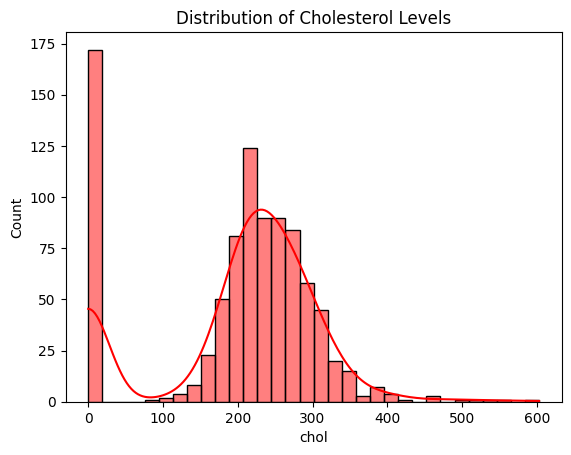

In [28]:
sns.histplot(df["chol"], kde=True,color="Red")
plt.title("Distribution of Cholesterol Levels")
plt.show()



### 1. Which variables do you pick for Skewness?
Skewness only makes sense for **Continuous Numerical Variables** (measurements that can be any number, like 120.5 or 180.2). You do **not** check skewness for categorical variables (like Sex or Chest Pain Type).

**In the Heart Disease dataset, you pick these 5:**
1.  **`age`**: To see if your dataset is mostly old people (Right-skewed) or young people (Left-skewed).
2.  **`trestbps` (Blood Pressure)**: Usually has a "Right Tail" because some people have dangerously high blood pressure.
3.  **`chol` (Cholesterol)**: Almost always has extreme outliers on the high end.
4.  **`thalach` (Max Heart Rate)**: Often "Left-skewed" because as we get older or sicker, our heart rate capacity drops.
5.  **`oldpeak` (ST Depression)**: This is the **most important** one for skewness. Most healthy people have 0. If someone has a 4 or 5, they are very sick. This creates a massive "Right Tail."

**Wizard Tip (The "Rule of Thumb"):**
If a variable has a **Skewness Score > 1 or < -1**, it is "Highly Skewed."
*   *Action:* You should consider a `Log Transform` or `Power Transform` to make the distribution look like a Bell Curve.

---

### 2. How do you pick variables for Multivariate Analysis?
You don't just pick "any" variables. You pick them based on three specific **Wizard Goals**:

#### Goal A: The "Signal Search" (Features vs. Target)
You want to see which variables actually "move the needle" for heart disease.
*   **The Move:** Plot `Target` against everything else.
*   **What to look for:** If you plot `Max Heart Rate` vs `Target` and you see that sick people (1) have significantly lower heart rates than healthy people (0), you have found a **Primary Signal**.

#### Goal B: The "Redundancy Check" (Feature vs. Feature)
You want to see if two variables are telling the exact same story. 
*   **The Move:** Look for high numbers in your Correlation Heatmap (e.g., > 0.80).
*   **What to look for:** In some datasets, `Age` and `Blood Pressure` might be so highly correlated that keeping both just "confuses" the model.
*   **The Decision:** If two variables are redundant, **drop the one that has a weaker correlation with the target.**

#### Goal C: The "Interaction Discovery" (Triangle of Truth)
Sometimes one variable is boring, but two together are explosive.
*   **Example:** `Cholesterol` by itself might not be that predictive. `Age` by itself might be okay. But **`Cholesterol` + `Age`** together might be the "Smoking Gun."
*   **The Move:** Use a `Pairplot` but color the dots by the `Target`.

---

### The Wizard's Python Logic for Selection

Instead of manually typing every name, use this code to automatically separate your "Skewness Candidates" from your "Categorical Signals."

```python
# 1. IDENTIFY CONTINUOUS VARIABLES (For Skewness & Scaling)
# We pick columns with more than, say, 10 unique values
continuous_vars = [col for col in df.columns if df[col].nunique() > 10]
print(f"Skewness Candidates: {continuous_vars}")

# 2. IDENTIFY CATEGORICAL VARIABLES (For Bivariate/One-Hot Encoding)
categorical_vars = [col for col in df.columns if df[col].nunique() <= 10 and col != 'target']
print(f"Categorical Signals: {categorical_vars}")

# --- THE SKEWNESS TEST ---
for col in continuous_vars:
    skew_val = df[col].skew()
    if abs(skew_val) > 0.75:
        print(f"WARNING: {col} is skewed ({skew_val:.2f}). Needs transformation!")

# --- THE MULTIVARIATE SEARCH ---
# Let's pick the top 3 continuous vars and top 3 categorical vars 
# to see how they interact with the target.
top_vars = ['age', 'thalach', 'oldpeak', 'cp', 'ca', 'thal']
sns.pairplot(df[top_vars + ['target']], hue='target', corner=True, palette='coolwarm')
plt.show()
```

### Summary of the Selection Mindset:
1.  **Skewness:** Only measurements (`age`, `chol`, `bp`).
2.  **Multivariate:** 
    *   Compare **measurement vs target** (to see the "gap" between sick and healthy).
    *   Compare **measurement vs measurement** (to find redundant "twins").
    *   Compare **category vs target** (to see which "types" of pain or sex are higher risk).

If you follow this, you aren't just "plotting data"; you are **filtering for truth.**

In [6]:
# . Use Automation Spells to analyze everything at once.

stats=df.describe().T
stats
stats['skew']=df.skew()
print(stats[['mean', 'std', '50%', 'skew']])

TypeError: Cannot perform reduction 'skew' with string dtype

In [ ]:
num_cols=['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes=plt.subplots(len(num_cols), 2, figsize=(28, 18))

for i, col in enumerate(num_cols):
    # Histogram shows the shape (skewnes)
    sns.histplot(df[col], kde=True, ax=axes[i,0], color='skyblue')
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
plt.tight_layout()
plt.show()


### Row 1: `age` (The Clean Witness)
*   **Analysis:** The histogram is beautifully symmetric (Bell Curve). The boxplot shows no dots outside the whiskers.
*   **Wizard Verdict:** This data is "Normal." It needs no special treatment other than standard scaling later.
*   **Math Check:** The Mean and Median are likely the same (~55).

### Row 2: `trestbps` (The Medical Mystery)
*   **Analysis:** Look at the far left of the histogram and boxplot. Do you see that tiny dot near **0**?
*   **The Crime:** A human being cannot have a resting blood pressure of 0 and be alive. 
*   **The Fix:** This is a "placeholder" for a missing value. You must find that row and replace the 0 with the **Median** (around 130).
*   **Math Check:** The right-side tail is "long," meaning it is **Right-Skewed**. You have several high-BP outliers (>175).

#### 1. Fix the "Zero Crimes" (Imputation)
You need to tell Python: "If BP or Cholesterol is 0, it's actually a mistake. Fix it."
```python
# Replace 0 with NaN so we can calculate the true median
df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['chol'] = df['chol'].replace(0, np.nan)

# Fill those NaNs with the median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
```

### Row 3: `chol` (The "Dead Man" Error)
*   **Analysis:** Again, look at the far left. You have a massive spike at **0**.
*   **The Crime:** Cholesterol of 0 is biologically impossible. Like the blood pressure, this is corrupted data or a missing value marked as 0.
*   **The Fix:** You **must** fix the 0s before training. If you don't, the model will think "Cholesterol of 0" is a real thing and get confused. 
*   **Math Check:** On the right side, you have a patient with cholesterol near **600**. This is a "Super Outlier."
  
#### Fix B: Robust Scaling (Best for `chol` and `trestbps`)
Because you have many outliers (circles), a standard `StandardScaler` will fail. It uses the **Mean**, which is easily fooled by outliers. You should use **`RobustScaler`**.
*   **Why:** It scales data using the **Median** and **IQR**, meaning it completely ignores the "circles" when deciding how to scale the rest of the data.

```python
from sklearn.preprocessing import RobustScaler

# Initialize the scaler
scaler = RobustScaler()

# Scale the columns that have outliers
cols_to_scale = ['trestbps', 'chol', 'thalach', 'oldpeak']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
```
### Row 4: `thalach` (Max Heart Rate)
*   **Analysis:** This is slightly **Left-Skewed** (the tail goes to the left).
*   **The Observation:** You have two outliers on the low end (around 70-80). 
*   **Wizard Verdict:** In a heart disease context, a very low Max Heart Rate is a huge "red flag" (Signal). Do not delete these outliers! They are likely your sickest patients.


#### Fix C: Capping / Winsorization (The "Last Resort")
If an outlier is truly crazy (like the cholesterol of 600) and you think it's a measurement error, you can "cap" it at the 99th percentile.

```python
# Any value above the 99th percentile gets set to the 99th percentile value
upper_limit = df['chol'].quantile(0.99)
df['chol'] = np.where(df['chol'] > upper_limit, upper_limit, df['chol'])
```

---

### Summary Checklist for your Heart Disease Data:
1.  **Check for 0s:** Fix those 0 values in `chol` and `trestbps` using the median (as we discussed in the last step).
2.  **Calculate Outliers:** Use the `find_outliers_iqr` function above to see exactly who those "circles" are.
3.  **Transform `oldpeak`:** Use `np.log1p` to fix that massive right-skewed wall.
4.  **Scale with `RobustScaler`:** This is your best defense against those circles during the actual machine learning phase.

### Row 5: `oldpeak` (The "Signal" Variable)
*   **Analysis:** This is **Highly Right-Skewed**. Look at the histogram; it’s basically a wall at 0.
*   **The Logic:** Most people (healthy) have 0. Only the sick people have values of 2, 4, or 6. 
*   **The Problem:** Linear models (Logistic Regression) hate this shape. They want a bell curve.
*   **Wizard Verdict:** This variable is the "Smoking Gun" for heart disease, but its shape is messy.


#### Fix A: The Log Transformation (Best for `oldpeak`)
For right-skewed data with zeros (like `oldpeak`), we use `log1p`. 
*   **Why:** `log(0)` is impossible (math error), so `log1p` adds 1 to everything before taking the log. This "squashes" the high values together.

```python
import numpy as np

# Apply Log Transformation to 'oldpeak'
df['oldpeak_log'] = np.log1p(df['oldpeak'])

# Now look at the new histogram—it will look much more like a Bell Curve!
sns.histplot(df['oldpeak_log'], kde=True)


```

### 2. The Code: How to calculate if a value is an outlier
To be 100% sure a value is an outlier, you use the **IQR Method** in your code. This is exactly what the box plot is doing behind the scenes.

```python
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- Outlier Report for {column} ---")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers found: {len(outliers)}")
    return outliers

# Try it on your Cholesterol column
chol_outliers = find_outliers_iqr(df, 'chol')
```

---

### 3. Fixing the Skewness (The Transformation Spells)
Skewness (like in your `oldpeak` plot) pulls the "tail" of the data too far. Linear models hate this because they try to "reach" for those far-away points, which ruins the accuracy for the normal points.


---

### Your "Wizard" To-Do List (What to do Next)

You cannot move to training yet. You must perform **Data Surgery** based on these plots:



#### 2. Address the Skewness in `oldpeak`
Since `oldpeak` is so skewed, standard scaling might not be enough. You should use a **RobustScaler** or a **Log Transformation** so the outliers don't "pull" the math too far.
*   *Math Principle:* A Log transform $log(1+x)$ "squashes" the high values (4, 5, 6) closer to the 0s, making the distribution look more like a bell.





In [36]:
df['trestbps']=df['trestbps'].replace(0, np.nan)
df['chol']=df['chol'].replace(0, np.nan)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [38]:
# Fill those NaNs with  the median
df['trestbps']=df['trestbps'].fillna(df['trestbps'].median())
df['chol']=df['chol'].fillna(df['chol'].median())

df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [44]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
cols_to_scale=['trestbps', 'chol', 'thalch', 'oldpeak']

df[cols_to_scale]=scaler.fit_transform(df[cols_to_scale])
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,0.75,-0.131980,True,lv hypertrophy,0.270270,False,1.200000,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,1.50,0.944162,False,lv hypertrophy,-0.864865,True,0.666667,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,-0.50,-0.213198,False,lv hypertrophy,-0.297297,True,1.400000,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,0.00,0.213198,False,normal,1.270270,False,2.000000,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,0.00,-0.720812,False,lv hypertrophy,0.864865,False,0.600000,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,-0.15,1.898477,True,st-t abnormality,0.378378,False,-0.333333,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,0.00,-2.040609,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,-0.40,-0.335025,True,st-t abnormality,-1.081081,False,-0.333333,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,0.00,2.954315,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- Outlier Report for {column} ---")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers found: {len(outliers)}")
    return outliers

# Try it on your Cholesterol column
chol_outliers = find_outliers_iqr(df, 'chol')

--- Outlier Report for chol ---
Lower Bound: 35.50, Upper Bound: 407.50
Total Outliers found: 183


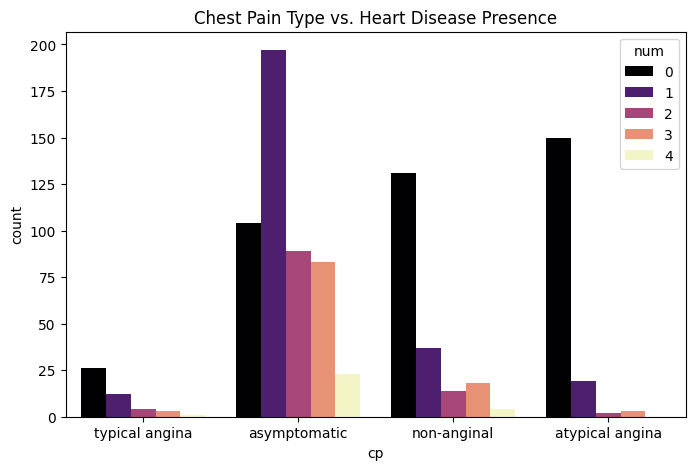

In [11]:
# --- 3. THE CATEGORICAL SIGNAL (Bivariate) ---
# Does Chest Pain (cp) actually predict Heart Disease?
# Wizard Move: We use a cross-tabulation to see the percentage.
plt.figure(figsize=(8, 5))
sns.countplot(x='cp', hue='num', data=df, palette='magma')
plt.title("Chest Pain Type vs. Heart Disease Presence")
plt.show()



In [13]:
# --- 4. THE CORRELATION HEATMAP (Multivariate) ---
plt.figure(figsize=(12, 8))
# We convert target to binary (0 = healthy, >0 = sick) for the correlation
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation: Looking for Redundancy")
plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 1200x800 with 0 Axes>